<img src="../figures/logos/logo_usc.jpg" align=right width='80px'/>
<br>

<table width="100%">
<td style="font-size:40px;font-style:italic;text-align:left;background-color:rgba(0, 220, 170,0.7)">
Quantum Phase Estimation
</td></table>


$ \renewcommand{\bra}[1]{\langle #1|} $
$ \renewcommand{\ket}[1]{|#1\rangle} $
$ \renewcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \renewcommand{\i}{{\color{blue} i}} $ 
$ \newcommand{\Hil}{{\cal H}} $
$ \newcommand{\cg}[1]{{\rm C}#1} $



In [1]:
import sys
sys.path.append('../')
import macro_tQ as tQ
import numpy as np

# Quantum Phase Estimation

 Let $U$ be a unitary operator and $\ket{u}$ an eigenvector. Since it is unitary, its eigenvalue is a complex phase 
<br>
<br>

$$
U \ket{u} = e^{2\pi i \varphi} \ket{u}\, ,
$$
<br>



$\Rightarrow~$ **Promise**: *we can prepare*  $\ket{u}$ and apply the operator $U$ <u>as many times as necessary<u> 


$\Rightarrow~$ **Problem**:  calculate the <u>*best possible approximation*</u> to $\varphi$. 

<div class="alert alert-block alert-danger">
<b> Note: </b> $~$    the eigenvalues  $\lambda = e^{i2\pi \varphi}=e^{i2\pi (\varphi+n)}$  are equal, for any integer $n\in {\mathbb Z}$. Therefore, it will be sufficient to consider values of $\varphi$ in the interval
    
$$\varphi \in [0,1)$$
    
to generate <i>all</i> the possible distinct eigenvalues $\lambda$.
</div> 
 
 


<br>
<figure>
<a id='fig_ref'></a>
<img src="./images/QPE.png" align=center width='50%'/>
<center></center>
</figure>
<br>

The QPE ("Quantum Phase Estimation") circuit is represented in the figure, where the first register has dimension $t$ and the input is the state $\ket{0}_t\otimes \ket{u}$.

- The dimension $t$ of the first register **will control the precision of our approximation** to $\varphi$.

- The dimension $n$ of the space to which $\ket{u}$ belongs is necessary to serve as the representation space for $U$.

If the first register has $t$ qubits $\{\ket{y}\}$ with $y \in S_t = 0,1,... 2^t-1$

the state generated by the circuit just before the Fourier transform

\begin{eqnarray}
\ket{0}_t \otimes \ket{u} ~ &\stackrel{H^t}{\longrightarrow} & ~  \sum_{y\in S_t}\ket{y} \otimes \ket{u} ~ =  \sum_{y_0...y_{t-1}=0,1}\ket{y_{t-1}}...\ket{y_0}\otimes \ket{u}  
\\   \rule{0mm}{10mm}
 &\stackrel{\cg{U^y}}{\longrightarrow} & \sum_{y_0...y_{t-1}=0,1}\ket{y_{t-1}}...\ket{y_0}\otimes U^{y_{t-1}2^{t-1}}...U^{y_0 2^{0}} \ket{u} \\  \rule{0mm}{10mm}
 &= & \sum_{y_0...y_{t-1}=0,1}\ket{y_{t-1}...y_0}\otimes U^{y_{t-1}2^{t-1}+...+y_0 2^{0}} \ket{u} \\  \rule{0mm}{10mm}
 && = \,    \sum_{y=0}^{2^t-1} \ket{y} \,  U^y\ket{u} \rule{0mm}{10mm}
\end{eqnarray}

**The key**: when $\ket{u}$ is an <i>eigenstate</i> of $U$, a <i>phase kickback</i> occurs 
<br>
<br>
\begin{eqnarray}
 \frac{1}{2^{t/2}} \sum_{y\in S_t} \ket{y} U^{y}\ket{u}  ~= ~  \frac{1}{2^{t/2}} \sum_{y\in S_t} \ket{y} \otimes e^{2\pi i \varphi y}  \ket{u} ~= ~ \frac{1}{2^{t/2}} \sum_{y=0}^{2^t-1} e^{2\pi i (2^t \varphi)  y/2^t} \ket{y} \otimes \ket{u}  \label{fase1}  
\end{eqnarray}

<u>Observe the first record</u> : it looks like the <i>Fourier transform</i> $\ket{\widetilde{2^t \varphi}}$ of the vector $\ket{2^t \varphi}$ 

$$
  \frac{1}{2^{t/2}} \sum_{y\in S_t} e^{2\pi i (2^t \varphi)  y/2^t} \ket{y}  
  = U_{TFC}\ket{2^t \varphi} =  \ket{\widetilde{2^t \varphi}}  
$$

 This would be correct if the number $2^t\varphi \in S_t$ *were an integer*

However, $2^t\varphi \notin {\mathbb Z}$ in general <b>will not be
an integer</b>!


  Let's then separate it in the following way into its *integer* part $a\in {\mathbb Z}$ and *mantissa* $\delta \in [0,1)$

$$
2^t \varphi  =a + \delta 
$$

<div class="alert alert-block alert-warning">
<b> Example: </b> if $\varphi = 0.4375 \in [0,1) $ then
<br>
    
- $ 2^2 \varphi = 1.75 \Rightarrow a=1~,~\delta = 0.75$ 
- $ 2^3 \varphi = 3.5~ \Rightarrow a=3~,~\delta = 0.5$ 
- $ 2^4 \varphi = 7  ~~~ \Rightarrow a=7~,~\delta = 0$
    
In essence, this is because $0.4375 = 7 / 2^{4}$ but if $\varphi$ were *irrational* there would be no $t$ for which $2^t\varphi$ has no mantissa.   
</div>

Let's finish the circuit

<br>
<figure>
<a id='fig_ref'></a>
<img src="./images/QPE.png" align=center width='50%'/>
<center></center>
</figure>
<br>


Introducing the variable change $2^t \varphi = a + \delta$, we will perform the inverse Fourier transform on the first register
<br>
<br>

\begin{eqnarray}
U^\dagger_{TFC} \frac{1}{\sqrt{2^t}} \sum_{y=0}^{2^t-1} e^{2\pi i \, (a + \delta) y/2^t} \ket{y} &=&\frac{1}{\sqrt{2^t}} \sum_{y=0}^{2^t-1} e^{2\pi i \, (a + \delta) y/2^t} U^\dagger_{TFC} \ket{y}
\\ \rule{0mm}{10mm}
~&=&~ \frac{1}{2^{t}} \sum_{y=0}^{2^t-1} e^{2\pi i (a + \delta) y/2^t}\left( \sum_{x=0}^{2^t-1}e^{-2\pi i yx/2^t}\ket{x} \right)   \\
~&=&~ \frac{1}{2^{t}} \sum_{x=0}^{2^t-1} \left(\sum_{y=0}^{2^t-1} e^{2\pi i (a + \delta -x) y/2^t} \right)\ket{x} ~ \equiv ~ \ket{\Phi}
\end{eqnarray}

<br>

If $\underline{\delta = 0}:~$ that is, if $2^t\varphi$ were an integer $a\in S_t = \{0, \ldots, 2^t-1\}$, 
 then the result
would be <b>exactly</b> $\ket{\Phi} = \ket{a} = \ket{2^t\varphi}$ 
<br>
<br>
\begin{eqnarray}
\ket{\Phi} &=&  \sum_{x=0}^{2^t-1} \frac{1}{2^{t}}  \left(\sum_{y=0}^{2^t-1}  e^{2\pi i (a-x) y/2^t} \right)\ket{x}  \\  \rule{0mm}{10mm}
&=&  \sum_{x=0}^{2^t-1}  \frac{1}{2^{t}} \left(2^t \delta_{x,a} \right)\ket{x}\\ \rule{0mm}{10mm}
&=& \ket{a}
\end{eqnarray}




In this case:

-    measuring the first register we would obtain a binary record of the number $a\in[0, 2^t-1]$

-    with $a$ we would recover the *desired phase* *exactly*.

$$
 \varphi = \frac{a}{2^t}  \in [0,1)
$$

If $\underline{\delta \neq 0}:~$ 

- The state in the first register $\ket{\Phi} = \sum_{x=0}^{2^t-1} f(x) \ket{x}$ will be a superposition. 
<br>
<br>

$$
\ket{\Phi} =  \sum_{x=0}^{2^t-1} \left( \frac{1}{2^{t}}\sum_{y=0}^{2^t-1}  e^{2\pi i (a + \delta  -x) y/2^t} \right) \ket{x}_t  
= \sum_{x=0}^{2^t-1} f(x) \ket{x}_t
$$
<br>



- A measurement will give the binary register of *an integer* $x \to m \in [0,2^t-1)$ with probability distribution $p(m) = |f(m)|^2$ centered at $m=a=[2^t\varphi]$


## Example

We are going to study this distribution by analyzing the unitary phase operator
<br>
<br>

$$
U =  \begin{bmatrix} e^{2\pi i \phi_0} & 0 \\ 0 & e^{2\pi i\phi_1}\end{bmatrix} 
$$
<br>

which has eigenstates $\ket{0}$ and $\ket{1}$ with eigenvalues $e^{2\pi\phi_0}$ and $e^{2\pi \phi_1}$ respectively. 
<br>
<br>


To program this operator, we note that 
<br>
<br>

$$
U =  
\begin{bmatrix} e^{2\pi i\phi_0} & 0 \\ 0 & e^{-2\pi i\phi_0}\end{bmatrix}
\begin{bmatrix} 1 & 0 \\ 0 & e^{2\pi i(\phi_0+\phi_1)}\end{bmatrix} = 
R_z(\theta = -4\pi \phi_0) \cdot P(\theta = 2\pi (\phi_1+\phi_0))
$$
<br>


The circuit requires the *controlled* version $\cg U^k$ of powers of this operator

In [2]:
def c_Uop(phi0,phi1,power):
    qcU = QuantumCircuit(1)  
    
    for _ in range(power):
        qcU.rz(-phi0*4*np.pi,0)
        qcU.p((phi1+phi0)*2*np.pi,0)
    
    qcU = qcU.to_gate()
    
    qcU.name = "c_U(%f ,%f)^%i" % (np.round(phi0,5), np.round(phi1,5),power)
    qcU = qcU.control()
    return qcU
    

To test the algorithm, we will select some values of $\phi_i = (\phi_0,\phi_1)$ in the form  

$$\phi_i = (a_i + \delta_i) 2^{-t}$$

In [3]:
t_seed=3

# case 0
a0 = 1.
delta0 = 0.1
phi0 = (a0+delta0)*2.**(-t_seed) 

# case 1
a1 = 3.
delta1 = 0.2
phi1 =(a1+ delta1)*2.**(-t_seed) 

print('phi0=', phi0, ' ->   2^t*phi0 = a0 + delta0 = ', 2**t_seed*phi0 , ' , a0 =' ,int(2**t_seed*phi0), '=>', format(int(2**t_seed*phi0),'b').zfill(t_seed) )
print('phi1=', phi1, ' ->   2^t*phi1 = a1 + delta1 = ', 2**t_seed*phi1 , ' , a1 =' ,int(2**t_seed*phi1), '=>', format(int(2**t_seed*phi1),'b').zfill(t_seed) )


phi0= 0.1375  ->   2^t*phi0 = a0 + delta0 =  1.1  , a0 = 1 => 001
phi1= 0.4  ->   2^t*phi1 = a1 + delta1 =  3.2  , a1 = 3 => 011


We build the QPE circuit

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
t = 9 # the width of the evaluation register
n = 1 # la width of the representation space circuit for U

qrt=QuantumRegister(t,name="t")
qra=QuantumRegister(n,name="qr_U") 
crt=ClassicalRegister(t)
qpe = QuantumCircuit(qrt,qra,crt)   

#initialize in the eigensta |u> =|0> or |u> = |1>
#qpe.x(qra)   
qpe.h(qrt)
qpe.barrier()

# apply the controlled operators c-U^j 
for j in range(t):
    qpe.append(c_Uop(phi0,phi1,2**j),[qrt[j]]+qra[:])
qpe.barrier()

# apply QFT^-1 
qpe.append(tQ.TFC_adj(t),qrt)

qpe.measure(qrt,crt)


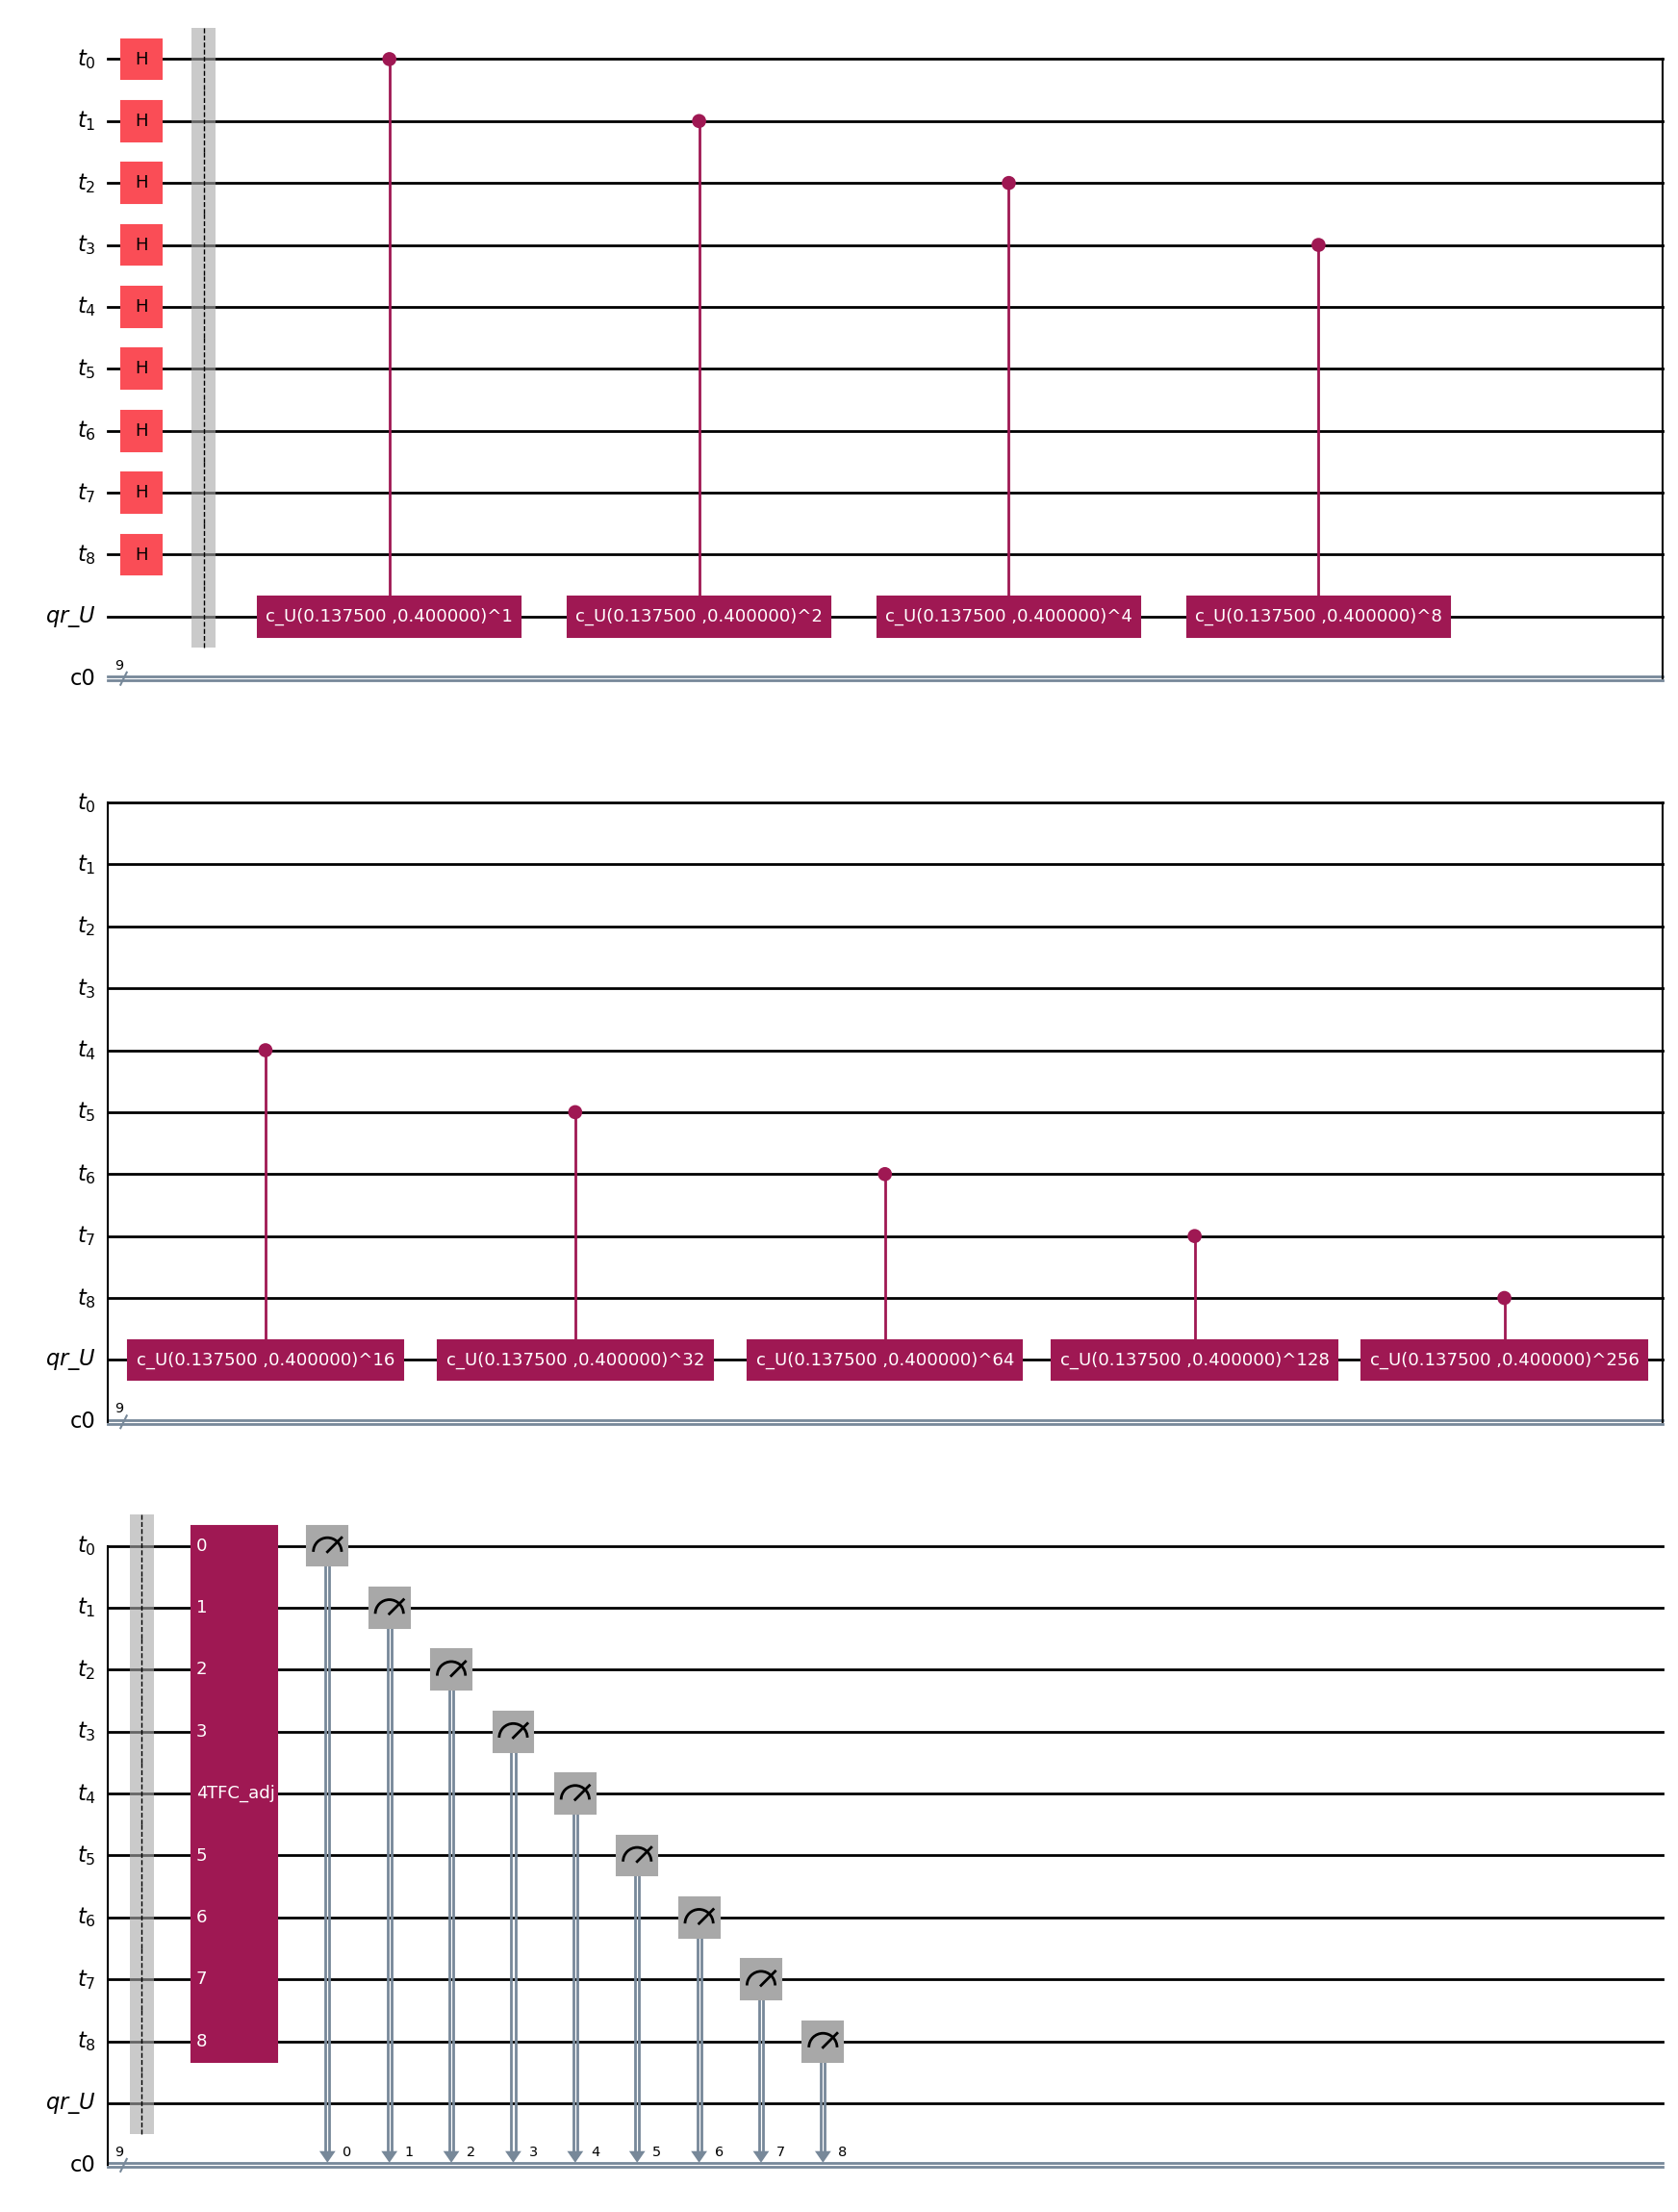

In [5]:
qpe.draw(output="mpl")

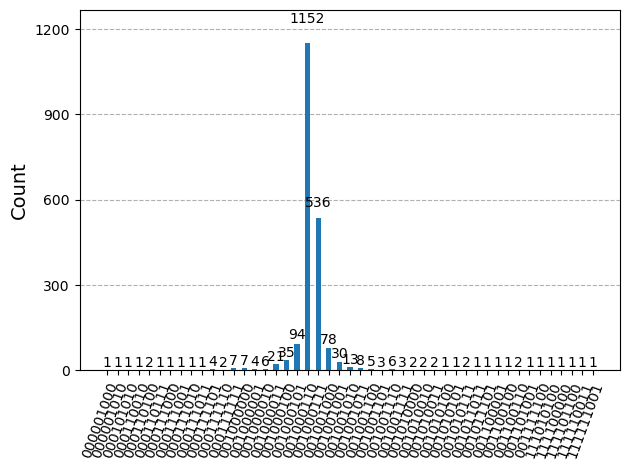

In [6]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.compiler import transpile

backend = AerSimulator()

counts = backend.run(transpile(qpe,backend), shots=2048).result().get_counts()
plot_histogram(counts)

From here we extract the approximation we have obtained.

In [7]:
max(counts, key=counts.get)

'001000110'

In [8]:
a_resultante = int(max(counts, key=counts.get),2)

# Select the eigenvalue associated to  |u> 
phi = phi0  # si |0>
#phi = phi1   # si |1>

print('the original value of phi was =', phi)

print('the best approximatio to the true value is a/2^t =', a_resultante*2**(-t))

print('the relative error is delta/(2^t phi) =', np.round(np.abs((phi -a_resultante*2**(-t))/phi),4))

the original value of phi was = 0.1375
the best approximatio to the true value is a/2^t = 0.13671875
the relative error is delta/(2^t phi) = 0.0057


## Distribution of Measures

For a fixed mantissa, $\delta \Rightarrow  \phi = a+\delta$, the different measurements of the resulting state $\ket{m}$ will be distributed around a *central value* $\ket{a} = \ket{[2^t\varphi]} $.

By writing $\ket{m=a+l}$, we can obtain the *probability distribution* $p(m) = p(\delta, l)$ of measuring $m=a+l$
<br>

\begin{eqnarray}
p(\delta, l) ~~&=&~~ \left\vert \,  \bra{a+ l} \,  \frac{1}{2^{t}}\sum_{x=0}^{2^t-1}   \sum_{y=0}^{2^t-1}  e^{2\pi i (\delta + a -x) y/2^t} \ket{x}  \,  \right\vert^2  ~~ \stackrel{x= a + l}{=} ~~
  \frac{1}{2^{2t}} \left\vert \,  \sum_{y=0}^{2^t-1} \left(e^{2\pi i (\delta-l) /2^t}\right)^y \,  \right\vert^2 
\end{eqnarray}

\begin{eqnarray}
&=& ~~  \frac{1}{2^{2t}} \left\vert\,  \frac{1- e^{2\pi i  \,  (\delta-l) }}{1- e^{2\pi i (\delta-l)/2^t}} \, \right\vert^2   ~= ~ 
\frac{1}{2^{2t}} \left\vert \, \frac{\sin \pi   (\delta-l)}{\sin (\pi(\delta-l)/2^t)} \, \right\vert^2 \, 
\hspace{2.5cm}
\end{eqnarray}


$$
\geq   \frac{1}{2^{2t}} \left(\frac{2 (\delta-l)}{\pi(\delta-l)/2^t }\right)^2 = \left(\frac{2}{\pi}\right)^2 \sim 0.405 \hspace{4cm}
$$

where we have used that $\pi x\geq \sin(\pi x) \geq 2 x$ for $x\in [ 0,\pi/2 ]$.


With a fixed $\delta$ up to $\delta = 0.5$, we see that the probability is *peaked* at $l=0$, that is, at $m=a$. From there, as expected, it is peaked at $l=1$. 
<br>
<br>
<center> 
<img src="./images/xprobeigenvalues.png" width='40%' style='margin:left'/>
</center>
<br>
<br>
The probability is never less than 0.405 at its maximum.

For a fixed $l = 0$, the probability of finding $m=a+0=a$ is 1 when $\delta=0$ and decreases with $\delta$. 
<br>
<br>
<center> 
<img src="./images/xmaxprobeigen.png" width='40%' style='margin:right'/>
</center>
<br>
<br>
When $l=1$, the maximum probability corresponds to the number $m=a+1$.


The **width $t$ of the auxiliary circuit** determines the width of the probability curve around the mean value.

This allows us to bound the approximation to the actual value of the sought phase according to the following theorem (see Nielsen p. 224)

<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Theorem:</b> 
<br>    
    the QPE (Quantum Phase Estimation) algorithm is capable of producing an <i>order $k$ estimate $m$</i> for the phase $\varphi$ (in the sense that $|\varphi- m/2^t |<2^{-k}$) with a probability $1-\epsilon$, taking a dimension of the representation space
<br>
<br>
$$
t \geq k  + \left[ \log\left(1 + \frac{1}{2\epsilon}\right) \right] \label{tedeene}
$$
</div>

## What if we can't prepare a self-state?

One of the premises used in the previous section is the possibility of preparing the eigenstate $\ket{\psi}$ of $U$ 

Otherwise, what *result* do we obtain after using the quantum phase estimation circuit?


Let's apply the previous circuit to an arbitrary vector $\ket{b}$. Generally, this vector can be expanded as

$$
\ket{b} = \sum_{i=1}^N c_i \ket{u_i}
$$
in the *eigenvector basis* of $U$

$$U\ket{u_i} = e^{2\pi i\varphi_i}\ket{u_i}$$  

Due to the linearity of the QPE circuit, at its output we will find a linear combination of states of the form

\begin{eqnarray}
U_{QPE}\, :\,\ket{0}_t \left(\sum_{i=1}c_i\ket{u_i}\right) &=& \sum_{i=1}c_i U_{QPE}\left(\ket{0}_t\ket{u_i}
\rule{0mm}{6mm}\right)  \\
&=& \sum_{i=1}^N  c_i \ket{\Phi_i}\ket{u_i} 
\\
&=& \sum_{i\in S_n}\sum_{x\in S_t} c_i \ket{x}\braket{x}{\Phi_i}\ket{u_i}
\\
&=& \sum_{i\in S_n}\sum_{x\in S_t} c_i \braket{x}{\Phi_i} \ket{x}\ket{u_i} 
\end{eqnarray}

Measuring in the first register $\ket{x}\hookrightarrow \ket{m}$ we will obtain an integer $\to m $ with probability

$$
p(m) = \sum_i  |c_i|^2  |\braket{m}{\Phi_i}|^2   = \sum_i  |c_i|^2  p(\delta_i,l_i)
$$


The probability $p(m)$ is a **weighted sum of distributions** $p(\delta_i,l_i) =  |\braket{m}{\Phi_i}|^2$
with $m = a_i + l_i$ *peaked* around $l_i = 0$.


If $t$ is chosen as in the theorem described above, the result will be an approximation $a_i$ to $2^t\varphi_i$ with a success probability of at least $|c_i|^2 (1-\epsilon)$.

*Example:*

Let's run the QPE circuit initializing for a combination

$$\ket{b} = \cos \theta/2 \ket{0} + \sin \theta/2
 \ket{1}= R_y(\theta)\ket{0}$$
 
 of eigenstates of $P(\varphi)$.

In [9]:
t_seed = 3

#eigenvalues of P
a0 = 1.
delta0 = 0.1
phi0 = (a0+ delta0)*2.**(-t_seed) 

a1 = 3.
delta1 = 0.2
phi1 =(a1+ delta1)*2.**(-t_seed) 


print('phi0=', phi0, ' ->   2^t*phi0 = a0 + delta0 = ', 2**t_seed*phi0 , ' , a0 =' ,int(2**t_seed*phi0), '=>', format(int(2**t_seed*phi0),'b').zfill(t_seed) )
print('phi1=', phi1, ' ->   2^t*phi1 = a1 + delta1 = ', 2**t_seed*phi1 , ' , a1 =' ,int(2**t_seed*phi0), '=>', format(int(2**t_seed*phi1),'b').zfill(t_seed) )


phi0= 0.1375  ->   2^t*phi0 = a0 + delta0 =  1.1  , a0 = 1 => 001
phi1= 0.4  ->   2^t*phi1 = a1 + delta1 =  3.2  , a1 = 1 => 011


In [10]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

t = 6 # the dimension of the evaluation space 
n = 1 # the dimension of the representation space of U

qrt=QuantumRegister(t,name="t")
qra=QuantumRegister(n,name="qr_U") # aquí 1 es la dimensión del espacio en el que opera U
crt=ClassicalRegister(t)

qpe = QuantumCircuit(qrt,qra,crt)   

##########################################################################
# initialize the ancilla in a combination  cos(th/2)|0> + sin(th/2)|1>
theta = 2*np.pi*0.25 
qpe.ry(theta,qra) 
##########################################################################

qpe.h(range(t))
qpe.barrier()

# apply controlled operators c-U^j 
for j in range(t):
    qpe.append(c_Uop(phi0,phi1,2**j),[qrt[j]]+qra[:])
#    qpe.cp(2*np.pi*phi1*(2**j), qrt[j], qra); # This is C-U
    

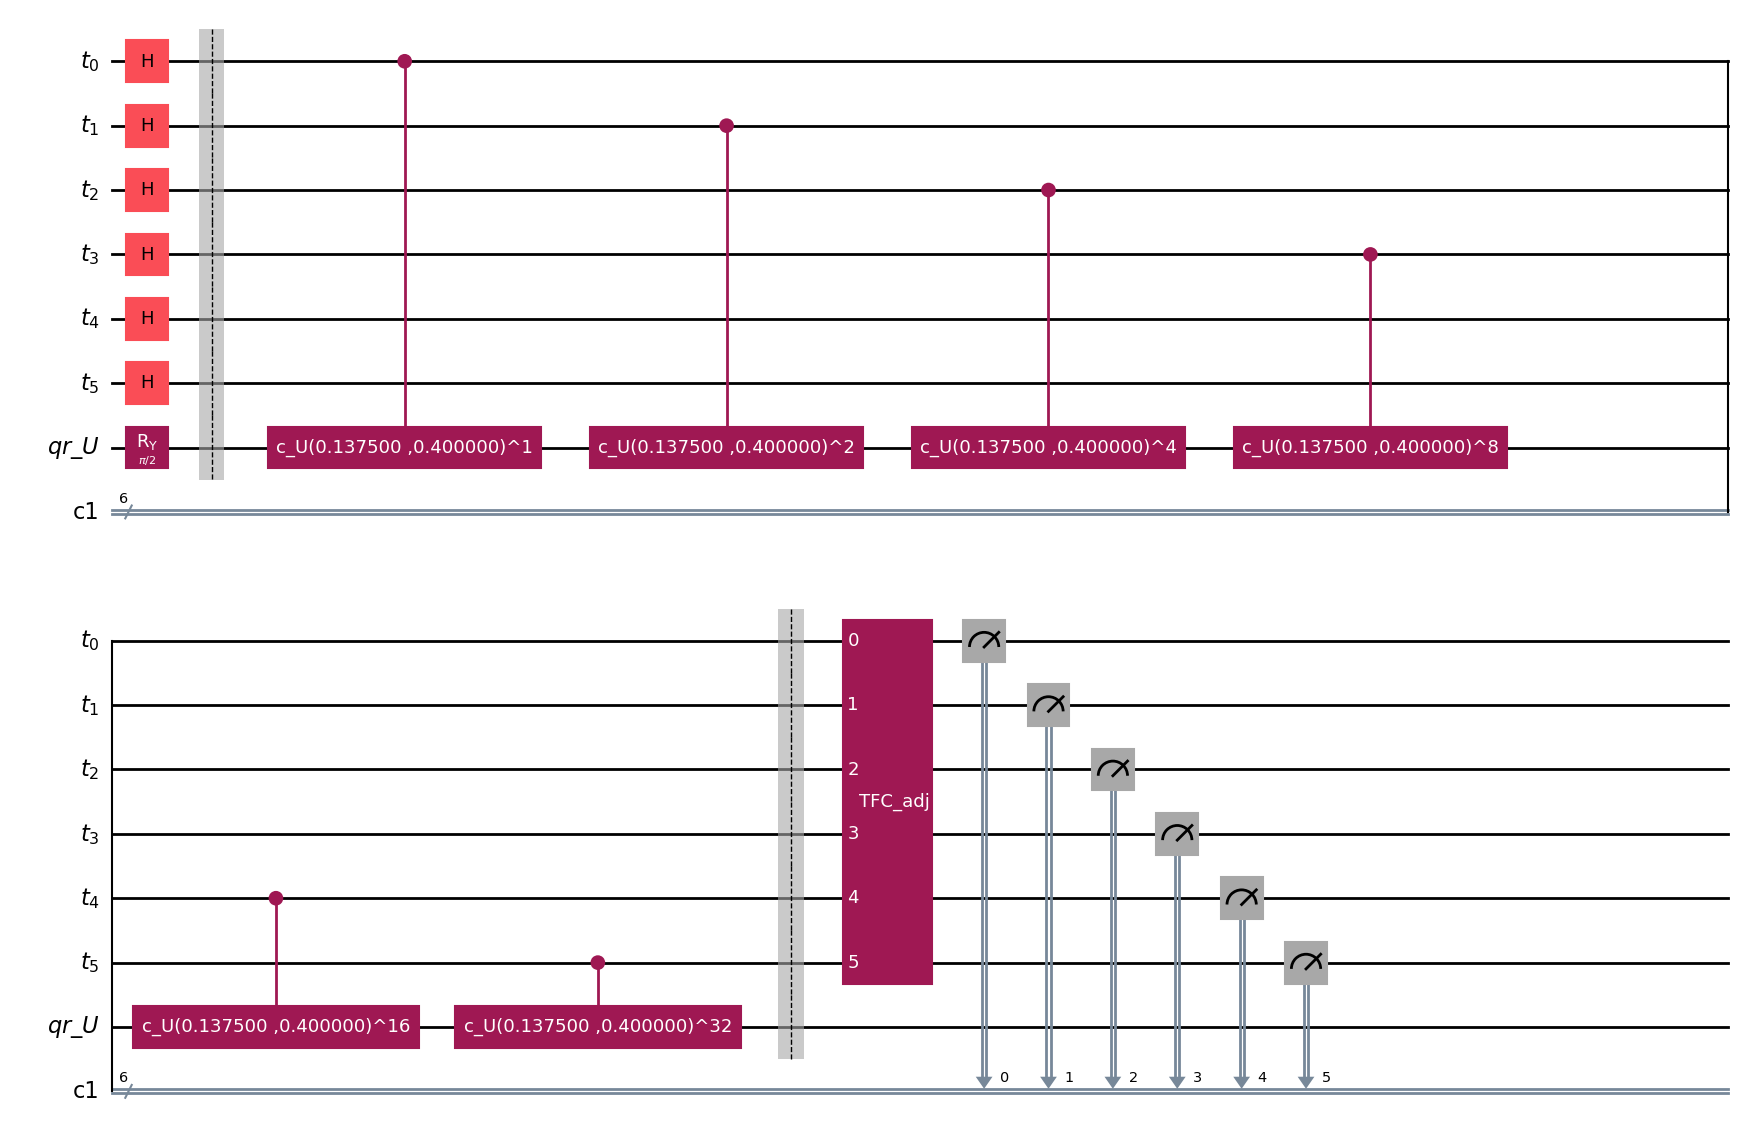

In [11]:
qpe.barrier()

# aplicamos la QFT^-1 que está definida en macro.py 
qpe.append(tQ.TFC_adj(t),qrt)

# using the qiskit libray
#from qiskit.circuit.library import QFT
#qpe.append(QFT(len(qr),do_swaps=True).inverse(),qr)

qpe.measure(qrt,crt)

qpe.draw(output="mpl")

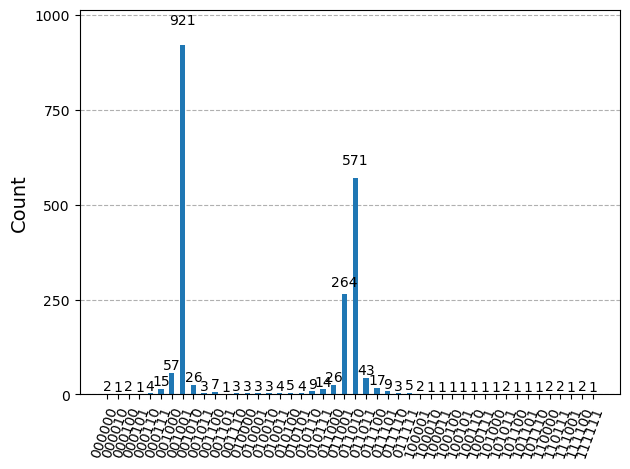

In [12]:
counts2 = backend.run(transpile(qpe,backend), shots=2048).result().get_counts()
plot_histogram(counts2)

# Modular Order

<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Definition</b> (Modular order): 
<br>
<br>
Let $m,N \in {\mathbb N}$ be two integers $m<N$ that are coprime (without common divisors).<br><br>
We define the <b> order of $m$ modulo $N$</b> as the smallest positive integer, $r$, such that $m^r = 1$ mod$N$.
</div>
<br>


**Problem**: given $m$ and $N$, find $r$ with the minimum number of operations.

*Example:*

In [28]:
{2,4,7,8,11,13}   # these are all coprime with N=15

#let us see the series m^i%N
m=7
N=15
[(m**i)%N for i in range(19)]

[1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4]

<div class="alert alert-block alert-danger">
In general, if $N=2^n$, classically there are no algorithms capable of solving this problem in a number of steps that is <i>polynomial in $n$</i>.

On the contrary, verifying if an $r$ is a solution is easy.
<br>
<br> 
    
We are faced with an NP-type problem.
<div>

<div class="alert alert-block alert-danger">
<b> Note: </b>
    
Since $m^r = 1 = m^0$, from that point on, the series of values $\{m^0,m^1,\ldots m^{r-1}\}$ repeats. 
Therefore, finding the <i> modular order </i> of $m$ modulo $N$ is the same as finding the <i> periodicity</i> of the function $f(x) = m^x\, $mod$N$. 
     
    
However, if we try to construct an oracle for the unitary operator $U_f:\ket{x}\ket{y} \to \ket{x}\ket{y m^x  \,{\rm mod} N}$ we will encounter exponential complexity.
</div>

Let $U ; \Hil_n \to \Hil_n $ be an oracle that acts in the following way on the basis $\{\ket{y}\}$ where $y \in S_n = {0,1,...,N-1}$.

$$
U\ket{y }  = \ket{m y \,{\rm mod} N}
$$


<div class="alert alert-block alert-danger">
A general oracle that works for any $(m,N)$ is not known.
</div>

The composition $U^x = \underbrace{U\cdot U \cdots U}_{x}$ generates all the vectors we are looking for

$$
U^x\ket{y }  = U^{x-1}\ket{m y \,{\rm mod} N} =  U^{x-2}\ket{m^2 y \,{\rm mod} N} = ... = \ket{m^x y \,{\rm mod} N}
$$


The *order* of $m$ mod$N$ is clearly the number $r$ such that 

$$U^{r }\ket{y} = \ket{m^r  y \,{\rm mod} N} = \ket{y}$$


With $U$ we could implement the function $f(x) = m^x{\rm mod} N$ in the form

$$
U_f \ket{x}\ket{1}  = \ket{x}U^x\ket{1} = \ket{x}\ket{m^x \, {\rm mod} N }
$$

and search for the periodicity of $f(x+r) = f(x)$ following the method from the previous lesson.

<div class="alert alert-block alert-danger">
<b> Note: </b>
<br>
    

- The action of $U_f$ is very similar to that of a controlled operator $\cg{U}\ket{x}\ket{y} = \ket{x}U^x\ket{y}$. However, now $x = 0,1,...,2^t-1$ is an integer. The circuit that implements $U_f$ is precisely the one used in the QPE circuit. 


- With this observation, we see that the QPE circuit is very similar to the one we used in period finding in the previous topic.
    

    
</b>    

We are going to apply the <i>Quantum Phase Estimation</i> (QPE) method to the operator $U$ 

Let's remember that this method <u>requires us to evaluate the operator $U$ on its eigenvectors</u> $U\ket{u} = e^{i\varphi}\ket{u}$.

If we *knew* $r$, we could construct the following set of $r$ vectors $\ket{u_s}$ with $s=0,...,r-1$ 
<br>
<br>
$$
\ket{u_s} = \frac{1}{\sqrt{r}} \sum_{j=0}^{r-1} e^{-2\pi i \frac{s }{r}j} U^j\ket{1}
$$
<br>


<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Theorem:</b> 
<br>
<br>
 The vectors   $\{\ket{u_s}\}$   form a set of <i>eigenvectors</i> of  $U$ with <i>eigenvalues</i> $e^{2\pi i s/r}~$. That is
<br>    
<br>
$$
U\ket{ u_s} = e^{i\varphi_s} \ket{u_s}
$$
<br>
with 
$$
\varphi_s = s/r~~~~~~ s=0,...,r-1
$$
<br>

**Test**:
\begin{eqnarray}
U \ket{u_s} &=& \frac{1}{\sqrt{r}} \sum_{j=0}^{r-1} e^{-2\pi i s j/r} U^{j+1}\ket{1} 
\nonumber\\
 &=& e^{2\pi i \frac{s}{r}}  \frac{1}{\sqrt{r}} \sum_{j=0}^{r-1} e^{-2\pi i  s (j+1)/r} U^{j+1}\ket{1} =
 e^{2\pi i \frac{s}{r}}  \frac{1}{\sqrt{r}} \sum_{j=0}^{r-1} e^{-2\pi i  s j/r} U^{j}\ket{1} 
\nonumber\\
&=& e^{2\pi i s/r} \ket{u_s}\, .  \rule{0mm}{8mm}
\end{eqnarray}


We could simply apply the phase estimation algorithm to *extract the series* of values of $\varphi_s = s/r$ and from there recover the *modular order* $r$.

The problem is that, to generate $\{\ket{u_s}\}$ we need to know $r$, which is *precisely the data we are looking for*.

An *important observation* allows us to bypass this difficulty: we are going to take a *homogeneous combination* of the eigenstates $\ket{u_s}$

<br>
<br>
\begin{eqnarray}
\frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}\ket{u_s}   &=& \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1} \left(  \frac{1}{\sqrt{r}}   \sum_{j=0}^{r-1} e^{-2\pi i  sj/r} U^{j}\ket{1} \right) ~=~ \frac{1}{r}   \sum_{j=0}^{r-1} \left(  \sum_{s=0}^{r-1}e^{-2\pi i  sj/r} \right)U^{j}\ket{1} \nonumber\\ 
\rule{0mm}{12mm}
&=&   \frac{1}{r}   \sum_{j=0}^{r-1} \, (r \delta_{j,0}) \,  U^{j}\ket{1} = U^0\ket{1} \nonumber\\  \rule{0mm}{10mm}
&=& \ket{1}
\end{eqnarray}
<br>


<u>The result is astonishingly simple!</u>:

if we initialize the phase estimation circuit with the state $\ket{0}_t\ket{1}_n$, at the output we will obtain a uniform superposition

$$
U_{QPE} : \ket{0}_t \otimes \ket{1}_n =U_{QPE} \left( \ket{0}_t\otimes\frac{1}{\sqrt{r}}\sum_{s=0}^{r-1} \ket{u_s} \right) ~ \to ~ \frac{1}{\sqrt{r}}\sum_{s=0}^{r-1} \ket{m_s}\otimes\ket{u_s}
$$

where $m_s = 2^t s/r$ as long as $t$ has been chosen such that $~2^t s/r \in {\mathbb Z}$ is an integer.


<center> 
<img src="./images/Orden_modular.png" width='60%' style='margin:left'/>
</center>


## **Example**:  
we need an oracle that implements the operation 

$$U^{x }\ket{y} = \ket{m^x  y \,{\rm mod} N} $$

The following code implements this oracle for $N=15$ and some coprime value of $m\in \{2,4,7,8,11,13\}$, and converts it into a controlled gate

In [30]:
def c_amod15(m, power):
    """Controlled multiplication by a mod 15"""
    if m not in [2,4,7,8,11,13]:
        raise ValueError("'a' must be 2,4,7,8,11 or 13")
    U = QuantumCircuit(4)        
    for iteration in range(power):
        if m in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if m in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if m in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
        if m in [7,11,13]:
            for q in range(4):
                U.x(q)
#    print(U)
    U = U.to_gate()
    U.name = "%i^%i mod 15" % (m, power)
    c_U = U.control()
    return c_U

Function defined in [Shor.ipynb](https://qiskit.org/textbook/ch-algorithms/shor.html)

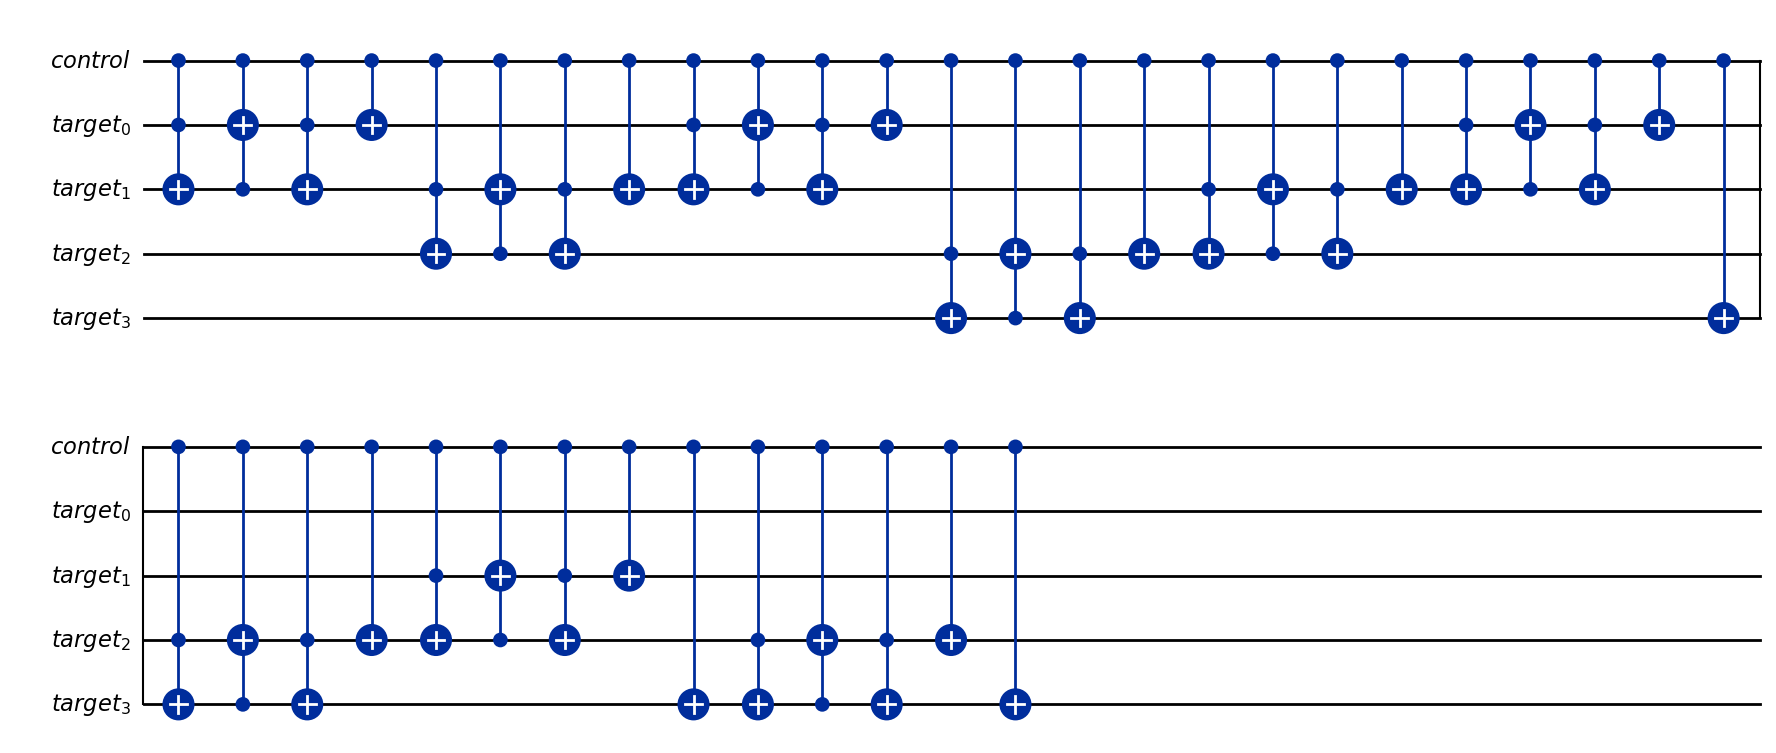

In [32]:
c_amod15(7,3 ).definition.draw('mpl')

<div class="alert alert-block alert-success">
<b>Exercise:</b>  <br>
build a circuit with this gate and verify that it reproduces the list $m^x$ mod 15 with $x=0,1,2,...$
</div>


Finally we apply the QPE estimation algorithm to obtain al the eigenvalues $\varphi_s = s/r$

In [33]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

t = 4 
n = 4 
m = 7

qr=QuantumRegister(t,name="t")
ar=QuantumRegister(4,name="qr_U") # aquí 1 es la dimensión del espacio en el que opera U
cr=ClassicalRegister(t)

qc = QuantumCircuit(qr,ar,cr)   

qc.x(ar[0]) #  inicializamos la ancilla al autoestado de P(phi) ->  |u> = |1>
#qpe.h(ar[0]) #  

qc.h(range(n))
qc.barrier()

# aplicamos los operadores controlados c-U^j 
for q in range(t):
    qc.append(c_amod15(m, 2**q), [qr[q]] + ar[:])



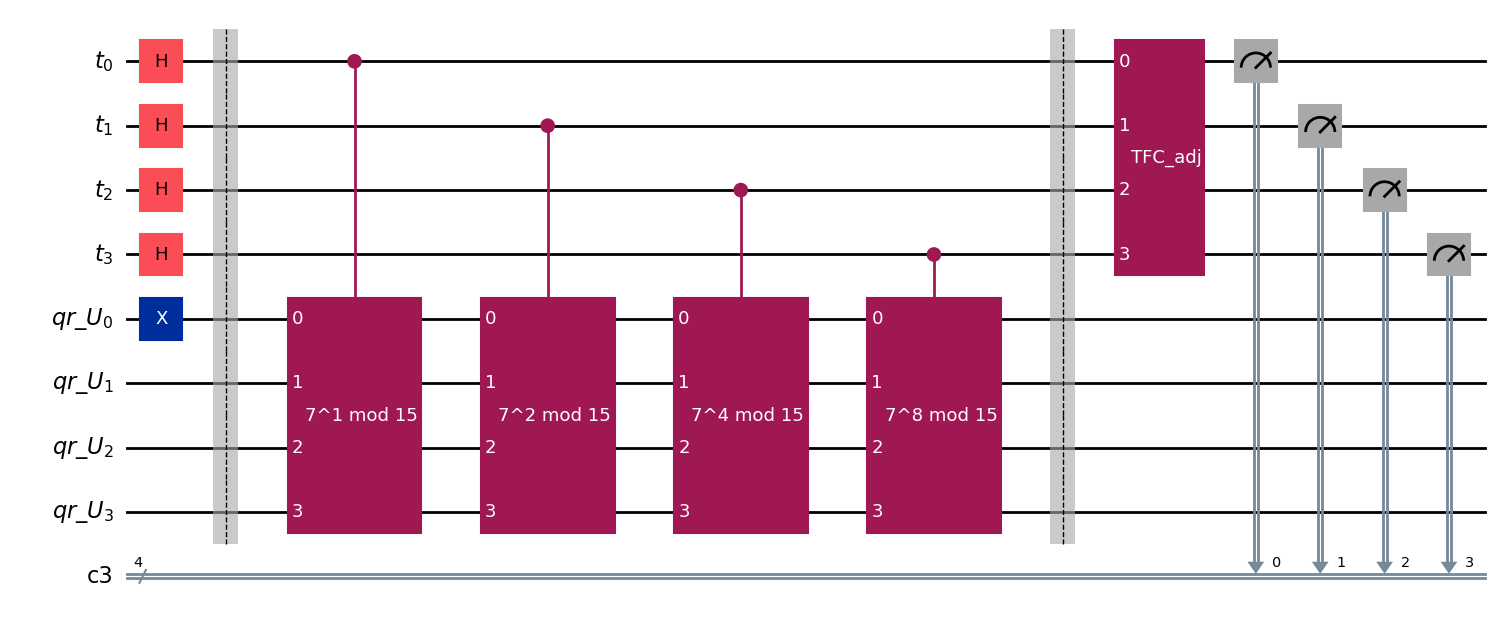

In [34]:
qc.barrier()

# aplicamos la QFT^-1 que está definida en macro.py 
qc.append(tQ.TFC_adj(t),qr)

# podemos hacerlo usando la librería de qiskit 
#from qiskit.circuit.library import QFT
#qpe.append(QFT(len(qr),do_swaps=True).inverse(),qr)


qc.measure(qr,cr)

qc.draw(output="mpl")

We run the circuit and list the most probable events

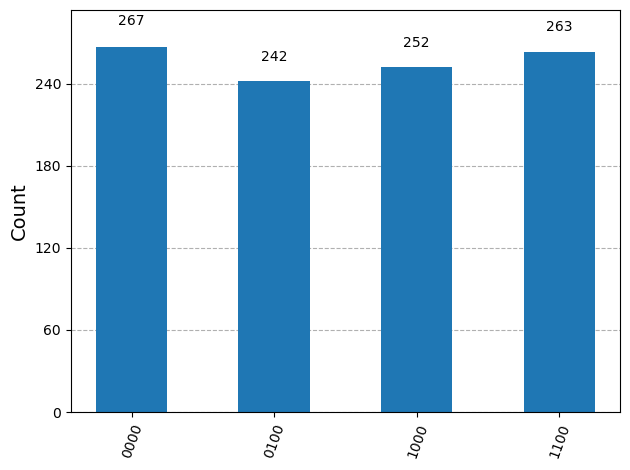

In [35]:
from qiskit_aer import AerSimulator
backend = AerSimulator()

counts = backend.run(transpile(qc,backend),shots = 1024).result().get_counts()


from qiskit.visualization import plot_histogram
plot_histogram(counts)

from here we obtain the list of integer values $2^t s/r$

In [38]:
print(counts)

Ns_list = sorted([int(keys,2) for  keys in counts])[1:] 
print('[2^ts/r] ~ ', Ns_list)

# dividiendo por 2**t
phis_list = [Ns_list[i]/2**t for i in range(len(Ns_list))]
print('phi_s', phis_list)


{'0000': 267, '1000': 252, '1100': 263, '0100': 242}
[2^ts/r] ~  [4, 8, 12]
phi_s [0.25, 0.5, 0.75]


Now we can use, as before, two strategies to extract the value of the period $r$:

1. analyzing the differences: $r = \displaystyle \left(\frac{s+1}{r} - \frac{s}{r}\right)^{-1}$

In [39]:
differences = [int((phis_list[s+1]-phis_list[s])**(-1)) for s in range(len(phis_list)-1)]

print(differences)

print('el valor entero del promedio =', int(sum(differences)/len(differences)))

[4, 4]
el valor entero del promedio = 4


2. using the representation in continued fractions: $\, \displaystyle \varphi_s = \frac{s}{r}$

In [21]:
from fractions import Fraction
print('[s/r]=',[Fraction(phis_list[i]).limit_denominator(20) for i in range(int(len(phis_list)))])

[s/r]= [Fraction(1, 4), Fraction(1, 2), Fraction(3, 4)]


<br>

<div class="alert alert-block alert-danger">
<b> Note: </b>
<br>

- In the most general case $\varphi_s = 2^t s/r \notin {\mathbb Z}$ will not be an integer
    

- Then the result of the measurement $m_s$ will follow a probability distribution <i>peaked</i> around the integer part $a_s = [2^t s/r]$
    

- By making a large number of measurements and selecting the most probable events $m_s = a_s$, we can recover $r$ using the same previous methods.
</div>